In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import time
# import scienceplots # better plots, requires latex installed
# plt.style.use(['science','grid'])

### Determinstic FEM

Solving linear variational problem.


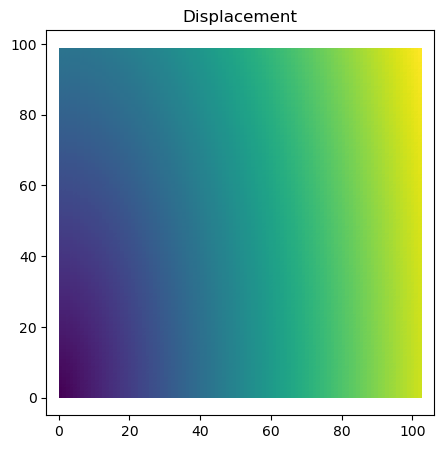

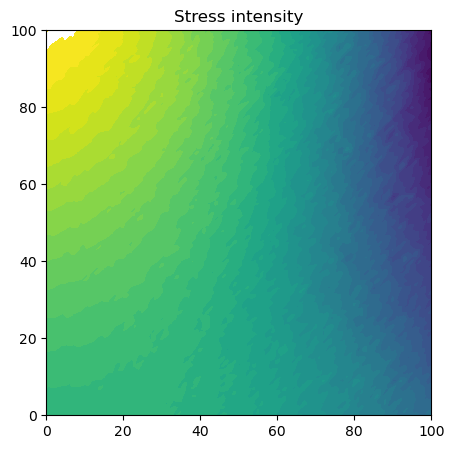

In [6]:
from fenics import *
import matplotlib.pyplot as plt

# It is generally safer to define Lmax as a float for mesh generation.
Lmax_value = 100.0
Lmax = Constant(Lmax_value)

# Create mesh and define function space
mesh = RectangleMesh(Point(0, 0), Point(Lmax_value, Lmax_value), 100, 100)
V = VectorFunctionSpace(mesh, 'P', 1)

# Material and load parameters
pstress = 0.1

# Material parameters: [mu, sigma, bx, by]
C11param = [1.55, 0.129, 20.18, 16.6]   
C33param = [0.316, 0.027, 20.86, 15.08]

# Compute Lamé parameters
lambda_ = np.exp(C11param[0]) - 2 * np.exp(C33param[0])
mu_ = np.exp(C33param[0])

tol = 1E-14

# Define boundary functions
def left_boundary(x, on_boundary):
    return on_boundary and near(x[0], 0, tol)

def bottom_boundary(x, on_boundary):
    return on_boundary and near(x[1], 0, tol)

def right_boundary(x, on_boundary):
    # Use Lmax_value for a float comparison
    return on_boundary and near(x[0], Lmax_value, tol)

# Define Dirichlet BCs: fix left (u_x = 0) and bottom (u_y = 0) boundaries.
bc1 = DirichletBC(V.sub(0), Constant(0), left_boundary)
bc2 = DirichletBC(V.sub(1), Constant(0), bottom_boundary)
bc = [bc1, bc2]

# Mark the right boundary for traction application
right = AutoSubDomain(right_boundary)
boundaries = MeshFunction("size_t", mesh, mesh.topology().dim() - 1)
boundaries.set_all(0)
right.mark(boundaries, 1)
ds = Measure('ds', domain=mesh, subdomain_data=boundaries)

# Define strain and stress operators.
# Note: d (the space dimension) is needed in sigma() and is defined later.
def epsilon(u):
    return 0.5 * (nabla_grad(u) + nabla_grad(u).T)

# We will define 'd' after creating the TrialFunction.
def sigma(u):
    return lambda_ * div(u) * Identity(d) + 2 * mu_ * epsilon(u)

# Define variational problem.
# Note: d is defined after u is created.
x = SpatialCoordinate(mesh)
u_trial = TrialFunction(V)
d = u_trial.geometric_dimension()  # space dimension (e.g., 2 for 2D)
v = TestFunction(V)
f = Constant((0, 0))  # body force

# Traction on the right boundary.
T = Constant((pstress, 0))

a = inner(sigma(u_trial), epsilon(v)) * dx
L = dot(f, v) * dx + dot(T, v) * ds(1)

# Compute solution
u = Function(V)
solve(a == L, u, bc)

# Plot displacement field
plt.figure(figsize=(5, 5))
plot(u, title='Displacement', mode='displacement')
plt.axis('equal')

# Compute and plot stress intensity (von Mises)
tensor_space = TensorFunctionSpace(mesh, 'P', 1)
stress_proj = project(sigma(u), tensor_space)
# Deviatoric stress
s = stress_proj - (1.0/3) * tr(stress_proj) * Identity(d)
von_Mises = sqrt(3.0/2 * inner(s, s))
scalar_space = FunctionSpace(mesh, 'P', 1)
von_Mises_proj = project(von_Mises, scalar_space)

plt.figure(figsize=(5, 5))
plot(von_Mises_proj, title='Stress intensity')

# Compute and plot magnitude of displacement
u_magnitude = sqrt(dot(u, u))
u_magnitude_proj = project(u_magnitude, scalar_space)

tensor_space = TensorFunctionSpace(mesh, 'P', 1)
strain = project(epsilon(u), tensor_space)
stress = project(sigma(u), tensor_space)

# Uncomment the following lines to save the results to file:
# File('elasticity/displacement.pvd') << u
# File('elasticity/von_mises.pvd') << von_Mises_proj
# File('elasticity/magnitude.pvd') << u_magnitude_proj

plt.show()


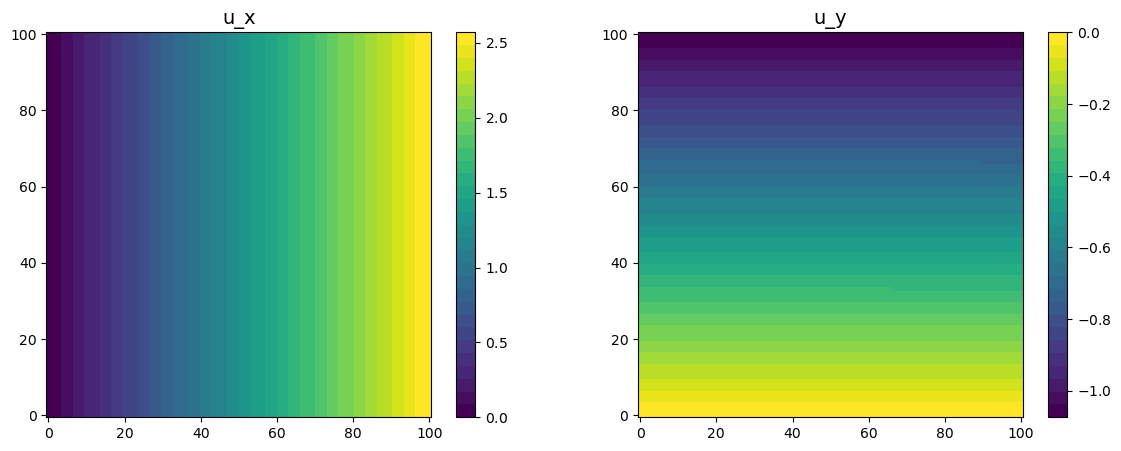

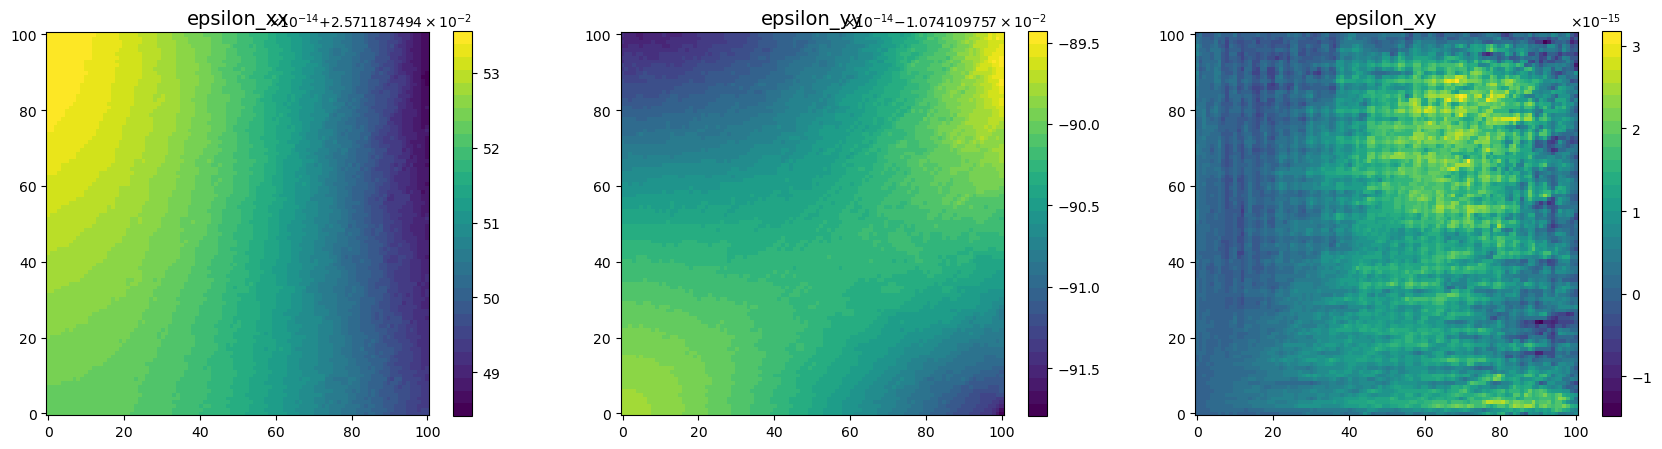

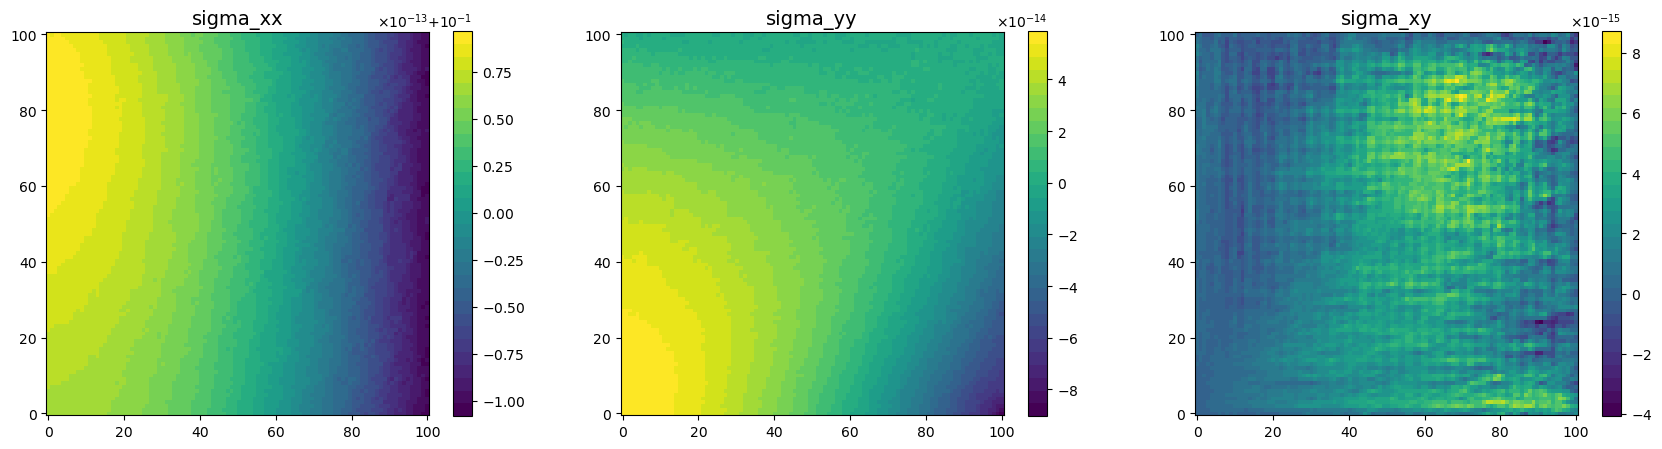

In [4]:
from matplotlib.colors import ListedColormap
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt


def pcolor_plot(AX, X, Y, C, title,colormap="copper",set_axis = 'on',colorbar=True,**kwargs):
    ## plot the pcolor plot of the given data C on the given axis AX with the given title and optional colorbar limits cmin and cmax
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 3))
    if len(kwargs) == 0:
        im = AX.pcolor(X, Y, C, cmap=colormap,shading='auto')
    else:
        cmin = kwargs["cmin"]
        cmax = kwargs["cmax"]
        im = AX.pcolor(X, Y, C, cmap=colormap, vmin=cmin, vmax=cmax,shading='auto')
    AX.set_aspect("equal", "box")
    AX.axis(set_axis)
    AX.set_title(title, fontsize=14)
    fig.colorbar(im, ax=AX, format=formatter)
    return im

cmap = plt.get_cmap('viridis')
num_colors = 30
color_values = [cmap(i) for i in np.linspace(0, 1, num_colors)]
cmap = ListedColormap(color_values)

n_mesh_points = 100

x_plot = np.linspace(0, Lmax_value, n_mesh_points)
y_plot = np.linspace(0, Lmax_value, n_mesh_points)
X, Y = np.meshgrid(x_plot, y_plot)

X_grid = np.hstack((X.flatten()[:, None], Y.flatten()[:, None]))

u_val = np.array([u(X_grid[i, :]) for i in range(X_grid.shape[0])])
strain_val = np.array([strain(X_grid[i, :]) for i in range(X_grid.shape[0])])
strain_val = np.array([strain_val[:,0], strain_val[:,3], 0.5*(strain_val[:,1]+strain_val[:,2])]).T
stress_val = np.array([stress(X_grid[i, :]) for i in range(X_grid.shape[0])])
stress_val = np.array([stress_val[:,0], stress_val[:,3], 0.5*(stress_val[:,1]+stress_val[:,2])]).T

# # Plot displacement
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
im = pcolor_plot(ax[0], X, Y, u_val[:,0].reshape(X.shape), "u_x",colormap=cmap)
im = pcolor_plot(ax[1], X, Y, u_val[:,1].reshape(X.shape), "u_y",colormap=cmap)

# # Plot strain
fig, ax = plt.subplots(1, 3, figsize=(21, 5))
im = pcolor_plot(ax[0], X, Y, strain_val[:,0].reshape(X.shape), "epsilon_xx",colormap=cmap)
im = pcolor_plot(ax[1], X, Y, strain_val[:,1].reshape(X.shape), "epsilon_yy",colormap=cmap)
im = pcolor_plot(ax[2], X, Y, strain_val[:,2].reshape(X.shape), "epsilon_xy",colormap=cmap)

# Plot stress
fig, ax = plt.subplots(1, 3, figsize=(21, 5))
im = pcolor_plot(ax[0], X, Y, stress_val[:,0].reshape(X.shape), "sigma_xx",colormap=cmap)
im = pcolor_plot(ax[1], X, Y, stress_val[:,1].reshape(X.shape), "sigma_yy",colormap=cmap)
im = pcolor_plot(ax[2], X, Y, stress_val[:,2].reshape(X.shape), "sigma_xy",colormap=cmap)

plt.show()

In [5]:
print(f"mean E_xx: {np.mean(strain_val[:,0])}")
print(f"mean E_yy: {np.mean(strain_val[:,1])}")
print(f"mean E_xy: {np.mean(strain_val[:,2])}")

print(f"Poisson's ratio: {-np.mean(strain_val[:,1])/np.mean(strain_val[:,0])} / {lambda_/(lambda_ + 2*mu_)}")

mean E_xx: 0.02571187493951528
mean E_yy: -0.010741097568904246
mean E_xy: 7.610475337192924e-16
Poisson's ratio: 0.4177485148077162 / 0.41774851480782954


## Monte-Carlo

In [11]:
#Compute the solution for multiple realizations

from tqdm import tqdm

N_sim = int(1e2)
set_log_level(LogLevel.ERROR)  # Limit the verbosity of FEniCS

C11param = [ 1.55, 0.129, 50, 50]   # = [ mu, sigma , bx, by] 
C33param = [ 0.316, 0.027, 50, 50]

U_C11 = np.random.randn(N_sim,truncation_order)
U_C33 = np.random.randn(N_sim,truncation_order)

# Compute random coefficients
C11 = C_from_xi(U_C11, eig_values_C11, eig_vectors_C11, C11param)
C33 = C_from_xi(U_C33, eig_values_C33, eig_vectors_C33, C33param)

# compute lambda and mu
lambda_ = C11 - 2*C33
mu = C33

Lmax = Constant(100)

# Create mesh and define function space
mesh = RectangleMesh(Point(0, 0), Point(Lmax, Lmax), 100, 100)
V_scalar = FunctionSpace(mesh, 'P', 1)  # Scalar function space
V = VectorFunctionSpace(mesh, 'P', 1)


mesh_coordinates = V_scalar.tabulate_dof_coordinates().reshape((-1, 2))  # Adjust shape for 3D if necessary


lambda_function = Function(V_scalar)
mu_function = Function(V_scalar)

pstress = 0.1
tol = 1E-14

def left_boundary(x, on_boundary):
    return on_boundary and near(x[0], 0, tol)

def bottom_boundary(x, on_boundary):
    return on_boundary and near(x[1], 0, tol)

def right_boundary(x, on_boundary):
    return on_boundary and near(x[0], Lmax, tol)

bc1 = DirichletBC(V.sub(0), Constant(0), left_boundary)
bc2 = DirichletBC(V.sub(1), Constant(0), bottom_boundary)
bc = [bc1, bc2]

#mark right boundary
right = AutoSubDomain(right_boundary)
boundaries = MeshFunction("size_t", mesh, mesh.topology().dim() - 1)
boundaries.set_all(0)
right.mark(boundaries, 1)
ds = Measure('ds', domain=mesh, subdomain_data=boundaries)


# Define strain and stress

def epsilon(u):
    return 0.5*(nabla_grad(u) + nabla_grad(u).T)
    #return sym(nabla_grad(u))

# Define variational problem
x = SpatialCoordinate(mesh)
u = TrialFunction(V)
v = TestFunction(V)
f = Constant((0, 0))
T = Constant((pstress, 0))
L = dot(f, v)*dx + dot(T, v)*ds(1)

u_sol = []
lambda_functions = []

for i in tqdm(range(N_sim)):
    interpolated_lambda_values = griddata(grid, lambda_[:,:,i].reshape(-1), mesh_coordinates, method='linear')
    interpolated_mu_values = griddata(grid, mu[:,:,i].reshape(-1), mesh_coordinates, method='linear')
    lambda_function = Function(V_scalar)
    mu_function = Function(V_scalar)
    lambda_function.vector()[:] = interpolated_lambda_values
    mu_function.vector()[:] = interpolated_mu_values
    sigma = lambda u: lambda_function*div(u)*Identity(d) + 2*mu_function*epsilon(u)

    u = TrialFunction(V)
    a = inner(sigma(u), epsilon(v))*dx

    # Compute solution
    u = Function(V)
    solve(a == L, u, bc)
    u_sol.append(u)
    lambda_functions.append(lambda_function)

u = u_sol[0]
# plt.figure(figsize=(5, 5))
# plot(u, title='Displacement', mode='displacement')

# Plot stress
stress = sigma(u) 
tensor_space = TensorFunctionSpace(mesh, 'P', 1)
stress = project(sigma(u), tensor_space)
s = sigma(u) - (1./3)*tr(sigma(u))*Identity(d)  # deviatoric stress
von_Mises = sqrt(3./2*inner(s, s))
V = FunctionSpace(mesh, 'P', 1)
von_Mises = project(von_Mises, V)
# plt.figure(figsize=(5, 5))
# plot(von_Mises, title='Stress intensity')

100%|██████████| 100/100 [00:29<00:00,  3.41it/s]


In [12]:
# Compute displacement mean and standard deviation 
u = np.stack([u.compute_vertex_values(mesh) for u in u_sol])

#save the reference solution
save = False
if save:
    np.save(f"MonteCarlo_u_1e{int(np.log10(N_sim))}.npy",u)

# MC_u = np.load(f"MonteCarlo_u_1e4.npy")
MC_u = u
u_mean = np.mean(MC_u,axis=0).reshape((2, -1))
u_std = np.std(MC_u,axis=0).reshape((2, -1))

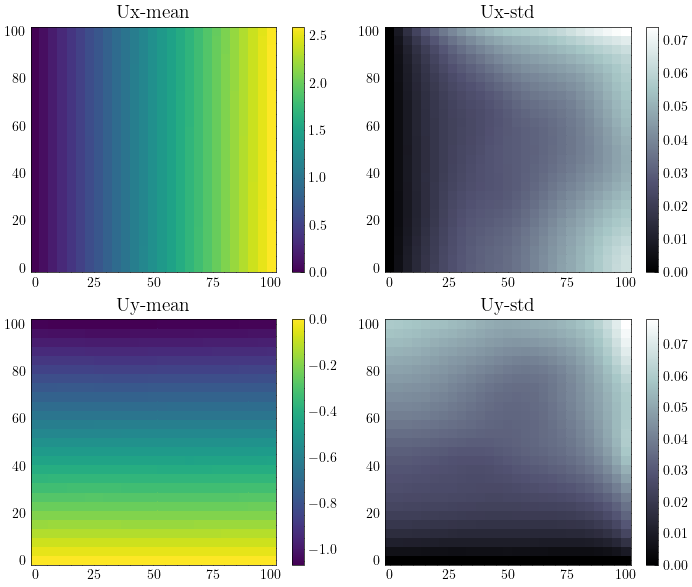

In [18]:
# Plot displacement
coordinates = mesh.coordinates()
grid_x, grid_y, u_mean_x = create_regular_grid(coordinates, u_mean[0, :],grid_res=27)
_, _, u_mean_y = create_regular_grid(coordinates, u_mean[1, :],grid_res=27)
_, _, u_std_x = create_regular_grid(coordinates, u_std[0, :],grid_res=27)
_, _, u_std_y = create_regular_grid(coordinates, u_std[1, :],grid_res=27)

fig, ax = plt.subplots(2, 2, figsize=(7.2, 6))
im = pcolor_plot(ax[0][0], grid_x, grid_y, u_mean_x, "Ux-mean",set_axis = 'on')
fig.colorbar(im, ax=ax[0][0])
im = pcolor_plot(ax[1][0], grid_x, grid_y, u_mean_y, "Uy-mean",set_axis = 'on')
fig.colorbar(im, ax=ax[1][0])
# plt.suptitle("Mean")

im = pcolor_plot(ax[0][1], grid_x, grid_y, u_std_x, "Ux-std",colormap="bone",set_axis = 'on')
fig.colorbar(im, ax=ax[0][1])
im = pcolor_plot(ax[1][1], grid_x, grid_y, u_std_y, "Uy-std",colormap="bone",set_axis = 'on')
fig.colorbar(im, ax=ax[1][1])
plt.tight_layout()
# fig.savefig('figures/MonteCarlo_u.pdf', dpi=300)